In [ ]:
"""
# Life Cycle Analysis (LCA) Tool Example

This script demonstrates the functionality of the LCA tool for analyzing environmental impacts 
of products throughout their life cycle.
"""

## 1. Setup and Data Loading

First, let's import the necessary modules and load our data.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
from src.data_input import DataInput
from src.calculations import LCACalculator
from src.visualization import LCAVisualizer

### Load Product Data
Load the sample product data from CSV file.

In [3]:
# Initialize data input handler
data_input = DataInput()

# Load product data
product_data = data_input.read_data('../data/raw/sample_data.csv')
print("Product Data Shape:", product_data.shape)
product_data.head()

Product Data Shape: (60, 14)


,product_id,product_name,life_cycle_stage,material_type,quantity_kg,energy_consumption_kwh,transport_distance_km,transport_mode,waste_generated_kg,recycling_rate,landfill_rate,incineration_rate,carbon_footprint_kg_co2e,water_usage_liters
0,P001,Reinforced Concrete,Manufacturing,Concrete,2500.0,120.0,50,Truck,125.0,0.1,0.80,0.10,350.0,150.0
1,P001,Reinforced Concrete,Transportation,Concrete,2500.0,20.0,100,Truck,0.0,0.0,0.00,0.00,75.0,0.0
2,P001,Reinforced Concrete,End-of-Life,Concrete,2500.0,50.0,30,Truck,2500.0,0.1,0.80,0.10,200.0,50.0
3,P002,Structural Steel Beam,Manufacturing,Steel,500.0,300.0,200,Truck,25.0,0.9,0.05,0.05,450.0,200.0
4,P002,Structural Steel Beam,Transportation,Steel,500.0,40.0,150,Truck,0.0,0.0,0.00,0.00,100.0,0.0


### Load Impact Factors
Load the environmental impact factors from JSON file.

In [4]:
# Load impact factors
impact_factors = data_input.read_impact_factors('../data/raw/impact_factors.json')
print("Available Materials:", list(impact_factors.keys()))
print("\nImpact Factors for Steel:")
pd.DataFrame(impact_factors['steel'])

Available Materials: ['steel', 'aluminum', 'plastic', 'paper', 'concrete', 'wood', 'clay', 'glass', 'copper', 'mineral_wool', 'cement']

Impact Factors for Steel:


,manufacturing,transportation,end-of-life
carbon_impact,1.8,0.5,0.1
carbon_unit,kg CO2e,kg CO2e,kg CO2e
energy_impact,20,5,1
energy_unit,MJ,MJ,MJ
water_impact,150,30,10
water_unit,L,L,L


## 2. Impact Calculations

Calculate environmental impacts using the LCACalculator.

In [5]:
# Initialize calculator
calculator = LCACalculator(impact_factors_path='../data/raw/impact_factors.json')

# Calculate impacts
impacts = calculator.calculate_impacts(product_data)
print("Calculated Impacts Shape:", impacts.shape)
impacts.head()

Calculated Impacts Shape: (60, 16)


,product_id,product_name,life_cycle_stage,material_type,quantity_kg,energy_consumption_mj,carbon_footprint_kg_co2e,water_usage_liters,transport_distance_km,waste_generated_kg,carbon_impact,energy_impact,water_impact,recycling_rate,landfill_rate,incineration_rate
0,P001,Reinforced Concrete,manufacturing,concrete,2500.0,431.999654,350.0,150000.0,50,125.0,350.0,4181.999654,300000.0,0.1,0.80,0.10
1,P001,Reinforced Concrete,transportation,concrete,2500.0,71.999942,75.0,0.0,100,0.0,75.0,821.999942,0.0,0.0,0.00,0.00
2,P001,Reinforced Concrete,end-of-life,concrete,2500.0,179.999856,200.0,50000.0,30,2500.0,200.0,2179.999856,100000.0,0.1,0.80,0.10
3,P002,Structural Steel Beam,manufacturing,steel,500.0,1079.999136,450.0,200000.0,200,25.0,900.0,11079.999136,275000.0,0.9,0.05,0.05
4,P002,Structural Steel Beam,transportation,steel,500.0,143.999885,100.0,0.0,150,0.0,250.0,2643.999885,15000.0,0.0,0.00,0.00


### Calculate Total Impacts
Aggregate impacts by product.

In [6]:
# Calculate total impacts
total_impacts = calculator.calculate_total_impacts(impacts)
print("Total Impacts by Product:")
total_impacts

Total Impacts by Product:


,product_id,product_name,carbon_impact,carbon_footprint_kg_co2e,energy_impact,energy_consumption_mj,water_impact,water_usage_liters,waste_generated_kg
0,P001,Reinforced Concrete,625.00,625.00,7183.999453,683.999453,400000.0,200000.0,2625.00
1,P002,Structural Steel Beam,1200.00,700.00,14331.998934,1331.998934,325000.0,230000.0,525.00
2,P003,Engineered Wood Beam,150.00,190.00,1877.999698,377.999698,110000.0,100000.0,105.00
3,P004,Clay Brick,6.00,6.00,139.199937,79.199937,12120.0,12000.0,2.75
4,P005,Glass Panel,440.00,440.00,5299.999280,899.999280,126500.0,115000.0,52.50
5,P006,Copper Wire,300.00,300.00,3665.999467,665.999467,66000.0,60000.0,10.50
6,P007,Aluminum Cladding,64.00,370.00,1449.999352,809.999352,76960.0,72000.0,21.00
7,P008,Insulation Board,0.00,225.00,449.999640,449.999640,48000.0,48000.0,15.75
8,P009,Plastic Pipe,0.00,175.00,341.999726,341.999726,35000.0,35000.0,5.25
9,P010,Cement Block,58.00,125.00,860.799775,280.799775,33000.0,30000.0,21.00


## 3. Visualization

Create various visualizations using the LCAVisualizer.

### Impact Breakdown by Material Type

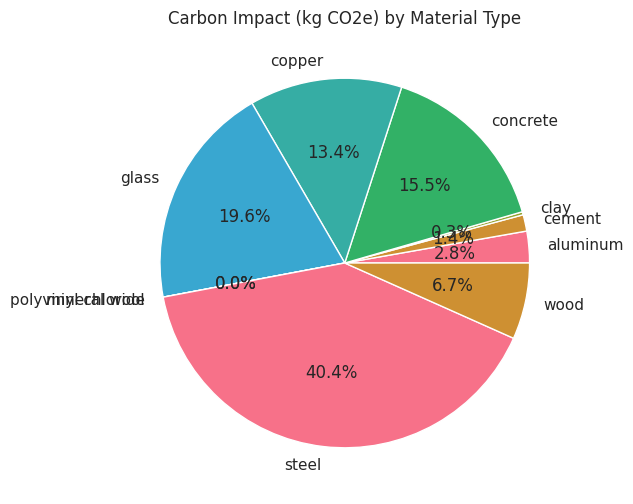

In [7]:
visualizer = LCAVisualizer()

# Plot carbon impact breakdown by material type
fig = visualizer.plot_impact_breakdown(impacts, 'carbon_impact', 'material_type')
plt.show()

### Life Cycle Impacts for a Specific Product

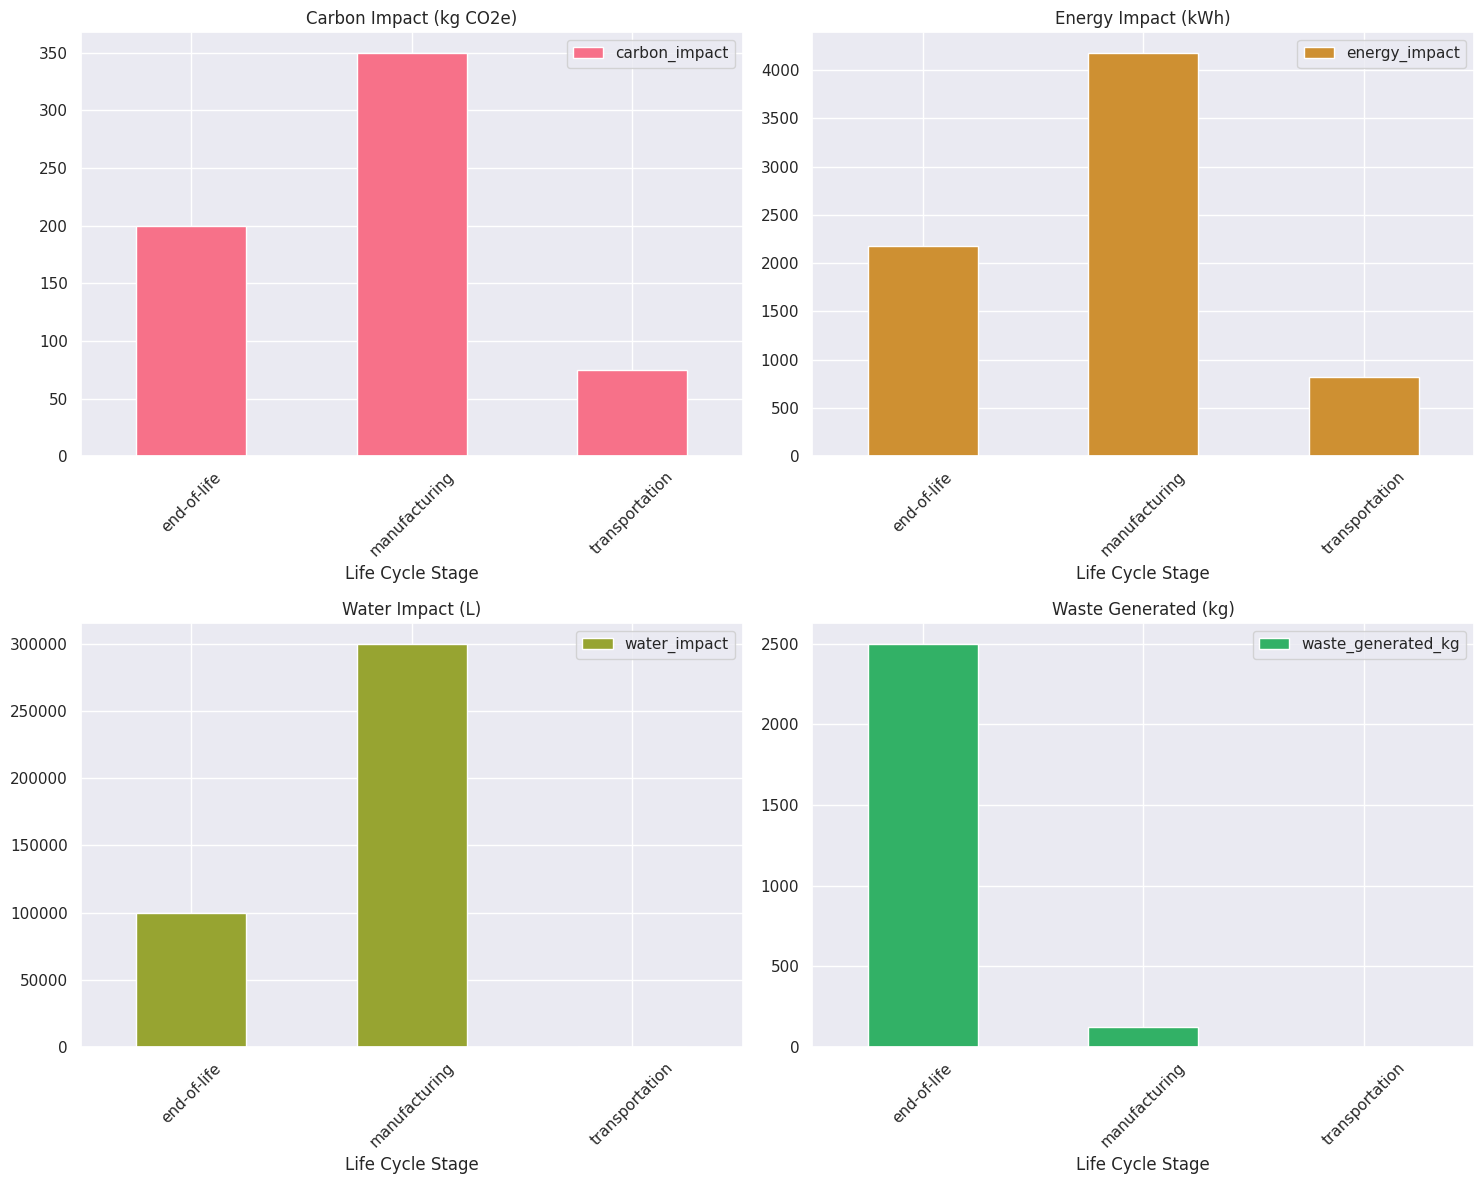

In [8]:
# Plot life cycle impacts for Product1
fig = visualizer.plot_life_cycle_impacts(impacts, 'P001')
plt.show()

### Product Comparison

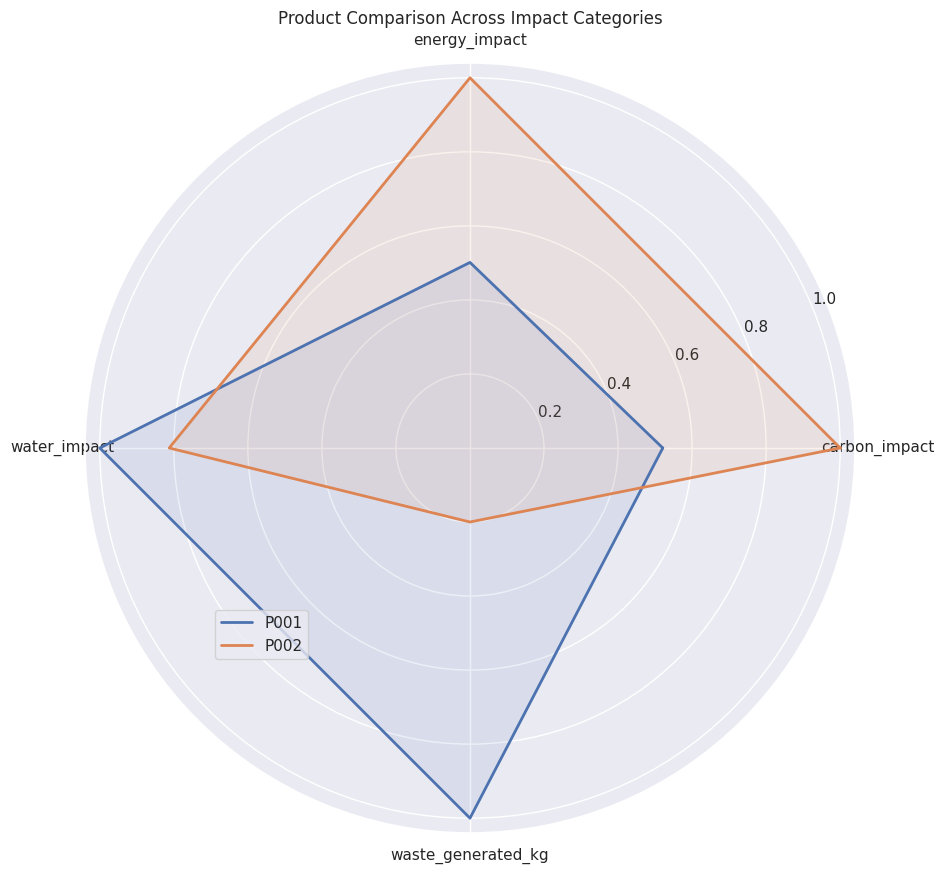

In [9]:
# Compare two products
fig = visualizer.plot_product_comparison(impacts, ['P001', 'P002'])
plt.show()

### End-of-Life Management

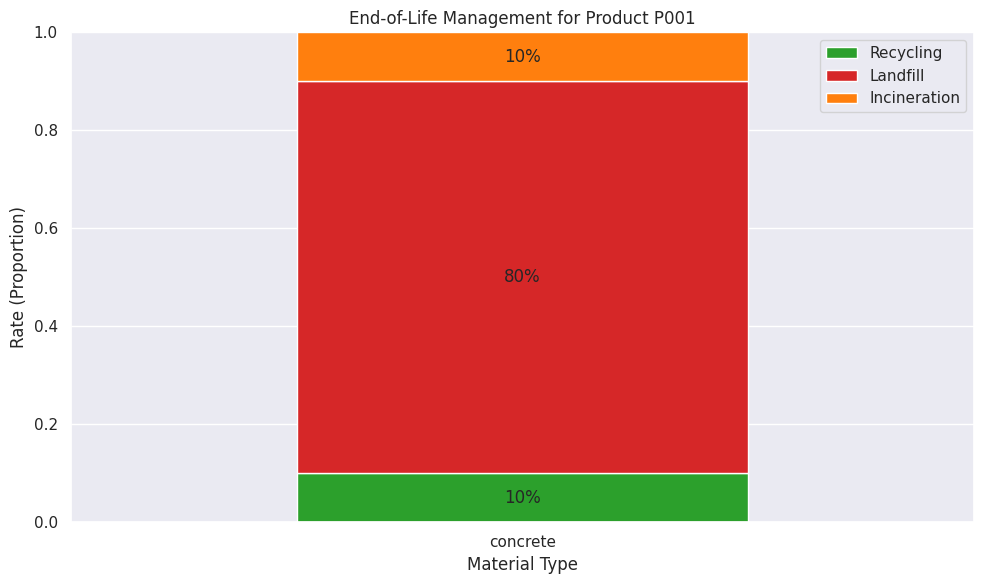

In [10]:
# Plot end-of-life breakdown for Product1
fig = visualizer.plot_end_of_life_breakdown(impacts, 'P001')
plt.show()

### Impact Category Correlations

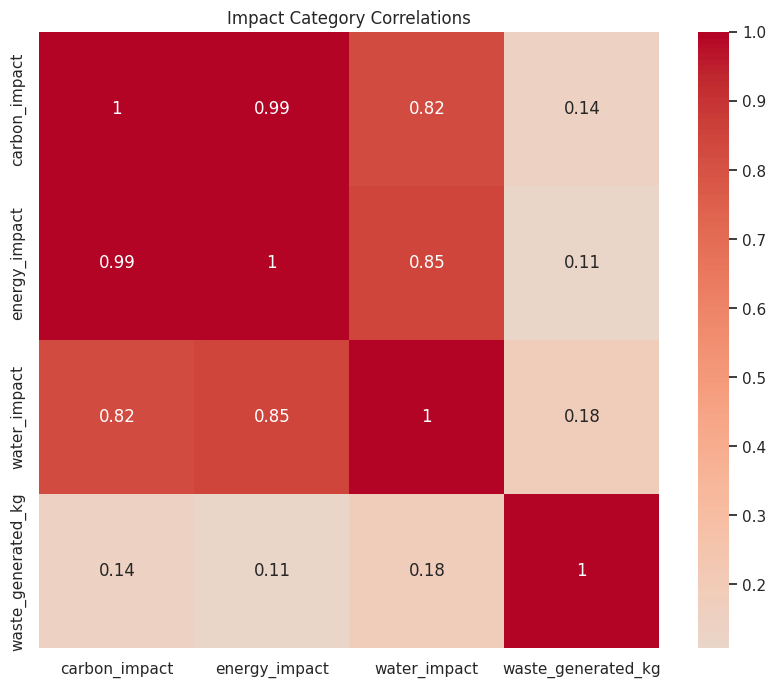

In [11]:
# Plot impact correlations
fig = visualizer.plot_impact_correlation(impacts)
plt.show()

## 4. Advanced Analysis

Perform more advanced analysis using the calculator's features.

### Normalize Impacts

In [12]:
# Normalize impacts for comparison
normalized_impacts = calculator.normalize_impacts(impacts)
print("Normalized Impacts:")
normalized_impacts.head()

Normalized Impacts:


,product_id,product_name,life_cycle_stage,material_type,quantity_kg,energy_consumption_mj,carbon_footprint_kg_co2e,water_usage_liters,transport_distance_km,waste_generated_kg,carbon_impact,energy_impact,water_impact,recycling_rate,landfill_rate,incineration_rate
0,P001,Reinforced Concrete,manufacturing,concrete,2500.0,431.999654,350.0,150000.0,50,125.0,0.388889,0.377437,1.000000,0.1,0.80,0.10
1,P001,Reinforced Concrete,transportation,concrete,2500.0,71.999942,75.0,0.0,100,0.0,0.083333,0.074188,0.000000,0.0,0.00,0.00
2,P001,Reinforced Concrete,end-of-life,concrete,2500.0,179.999856,200.0,50000.0,30,2500.0,0.222222,0.196751,0.333333,0.1,0.80,0.10
3,P002,Structural Steel Beam,manufacturing,steel,500.0,1079.999136,450.0,200000.0,200,25.0,1.000000,1.000000,0.916667,0.9,0.05,0.05
4,P002,Structural Steel Beam,transportation,steel,500.0,143.999885,100.0,0.0,150,0.0,0.277778,0.238628,0.050000,0.0,0.00,0.00


### Compare Alternatives

In [13]:
# Compare alternative products
comparison = calculator.compare_alternatives(impacts, ['P001', 'P002'])
print("Product Comparison:")
comparison 

Product Comparison:


,product_id,product_name,carbon_impact,carbon_footprint_kg_co2e,energy_impact,energy_consumption_mj,water_impact,water_usage_liters,waste_generated_kg,carbon_impact_relative,energy_impact_relative,water_impact_relative
0,P001,Reinforced Concrete,625.0,625.0,7183.999453,683.999453,400000.0,200000.0,2625.0,0.0,0.000000,23.076923
1,P002,Structural Steel Beam,1200.0,700.0,14331.998934,1331.998934,325000.0,230000.0,525.0,92.0,99.498887,0.000000
